In [82]:
## Data preprocessing

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# print("\nHead:\n", df.head())
print("\nHead:\n")
display(df.head())


Head:



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [84]:
# Shape of the dataset
print("\nShape:\n", df.shape)


Shape:
 (891, 12)


In [85]:

print("\nColumns:\n", df.columns.tolist())


Columns:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [86]:

print("\nData types:\n", df.dtypes)


Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [87]:

print("\nStatistical summary:")
display(df.describe())


Statistical summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [88]:
print("\nCategorical columns:\n")
display(df.select_dtypes(include='object').columns.tolist())


Categorical columns:



['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [89]:
print("\nNumerical colums:\n")
display(df.select_dtypes(include=np.number).columns.tolist())


Numerical colums:



['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [90]:
# Check for the missing values in the dataset

missing = df.isnull().sum()

missing_percentage = missing / len(df) * 100

missing_table = pd.DataFrame({
    "Missing count": missing,
    "Missing percentage": missing_percentage,
})

display(missing_table)

,Missing count,Missing percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


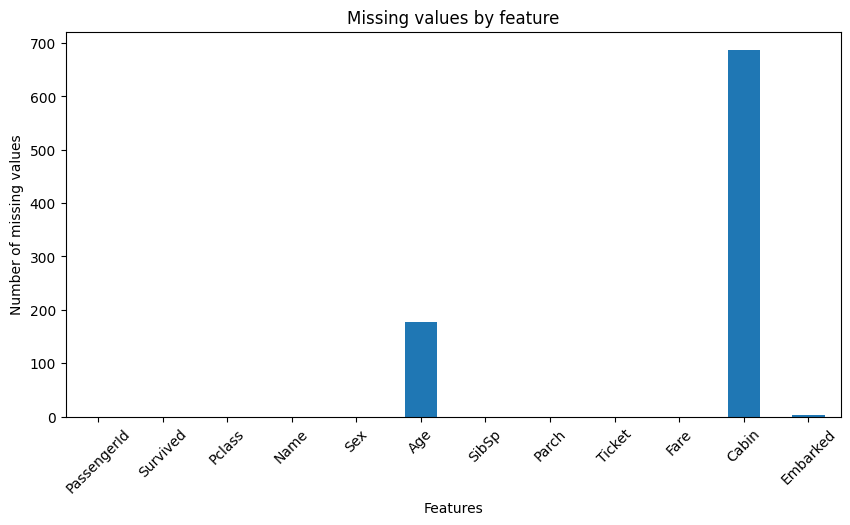

In [91]:
plt.figure(figsize=(10, 5))
missing.plot(kind='bar')

plt.title("Missing values by feature")
plt.xlabel("Features")
plt.ylabel("Number of missing values")

plt.xticks(rotation=45)
plt.show()

In [92]:
print("\nDuplicate values:\n", df.duplicated().sum())


Duplicate values:
 0


In [93]:
# Replace missing values by mean

df_mean = df.copy()

mean_age = df_mean["Age"].mean()

df_mean["Age"] = df_mean["Age"].fillna(mean_age)

print("Remaining missing values: ", df_mean["Age"].isnull().sum())

Remaining missing values:  0


In [95]:
# Replace missing valies by median

df_median = df.copy()

median_age = df_median["Age"].median()

df_median["Age"] = df_median["Age"].fillna(median_age)

print("Remaining missing values: ", df_median["Age"].isnull().sum())

Remaining missing values:  0


In [99]:
print("Mean age  : ", df["Age"].mean())
print("Median age: ", df["Age"].median())

Mean age  :  29.69911764705882
Median age:  28.0


In [102]:
# Replacing the missing values by the mode - Categorical values

df_mode = df.copy()

mode_embarked = df_mode["Embarked"].mode()[0]

df_mode["Embarked"] = df_mode["Embarked"].fillna(mode_embarked)

print("Remaining missing Embarked values: ", df_mode["Embarked"].isnull().sum())

Remaining missing Embarked values:  0


In [111]:
why_mode_0 = df_mode["Embarked"].mode()
print(why_mode_0)

0    S
Name: Embarked, dtype: object


In [123]:
# Encoding - One-hot encoder

print(df[["Sex", "Embarked"]].head(10))

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = encoder.fit_transform(df[["Sex", "Embarked"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Sex", "Embarked"])
)

display(encoded_df.head())

      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0


In [124]:
# Encoding - Label

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Survived_encoded"] = le.fit_transform(df['Survived'])

display(df[["Survived", "Survived_encoded"]].head())

,Survived,Survived_encoded
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


In [129]:
df["Embarked_encoded"] = le.fit_transform(df["Embarked"])

display(df[["Embarked", "Embarked_encoded"]].head(10))

,Embarked,Embarked_encoded
0,S,2
1,C,0
2,S,2
3,S,2
4,S,2
5,Q,1
6,S,2
7,S,2
8,S,2
9,C,0


In [138]:
# Min max scaling

features = df[["Age", "Fare"]].dropna()

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

scaled_minmax = minmax.fit_transform(features)

minmax_df = pd.DataFrame(
    scaled_minmax,
    columns=['Age', 'Fare']
)

display(features.head())
display(minmax_df.head())

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


In [141]:
# Standarization

from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

scaled_standard = standard.fit_transform(features)

standard_df = pd.DataFrame(
    scaled_standard,
    columns=["Age", "Fare"]
)

display(features.head())
display(standard_df.head())

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


,Age,Fare
0,-0.530377,-0.518978
1,0.571831,0.691897
2,-0.254825,-0.506214
3,0.365167,0.348049
4,0.365167,-0.503850
